# A one-hidden-layer multilayer perceptron

An MLP approximates a function by composing affine transformations with a nonlinear activation. In this notebook the input and output are both one-dimensional, so the learned function can be plotted directly. That makes the effect of hidden-layer width visible without hiding it behind a high-dimensional classification metric.

The target is smooth but contains two frequencies. A linear model can only produce a line, whereas a hidden layer can combine shifted and scaled nonlinear responses to form bends. The experiment follows the model from its definition to the approximation error, then compares widths under the same training setup.


## Model

With one hidden layer, the network is

```text
f(x) = W2 sigma(W1 x + b1) + b2
```

Each hidden unit first creates an affine response `w1_j x + b1_j`, then applies the activation. The output layer forms a learned linear combination of those hidden responses. The nonlinear activation is essential: without it, the composition of two affine maps is still affine, regardless of the hidden width.

The implementation uses PyTorch tensors and automatic differentiation. The parameters are not hand-coded update variables here; this notebook is about the expressive role of the architecture and about training a small network with the same framework used for larger models.


## Universal approximation theorem

The universal approximation theorem states, informally, that a feed-forward network with one hidden layer can approximate any continuous function on a compact interval to arbitrary accuracy when the activation is suitable and the hidden layer is wide enough. The theorem is an existence result. It does not say that a small network will train easily, that the required width is modest, or that the approximation will extrapolate outside the interval.

The width sweep below is a concrete one-dimensional illustration rather than a proof. Increasing the number of units gives the model more basis functions with which to represent the target. The fit can therefore improve, but the optimization procedure and the finite training set still determine what is actually learned.


## The target function and training data

The target is

```text
sin(2x) + 0.25 cos(7x)
```

The lower-frequency term controls the broad shape and the smaller higher-frequency term adds local variation. Training points are sampled on a fixed interval and the target is evaluated without observation noise. Because the target is deterministic, the plotted error reflects approximation and optimization error rather than irreducible measurement noise.

The training interval is also the only region in which the approximation is being assessed. A network can fit the interval well while behaving arbitrarily outside it; that is a consequence of the finite training domain, not a contradiction of the theorem.


In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(8)
torch.set_num_threads(1)

def target(x):
    return torch.sin(2 * x) + 0.25 * torch.cos(7 * x)

x = torch.linspace(-np.pi, np.pi, 500).unsqueeze(1)
y = target(x)
train_x, train_y = x[::2], y[::2]
plot_x, plot_y = x, y

class OneHiddenLayer(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, x):
        return self.network(x)

print('target range:', (y.min().item(), y.max().item()))
print('training points:', len(train_x))

target range: (-1.2310584783554077, 1.2308553457260132)
training points: 250


In [2]:
def fit_width(width, epochs=1_800, lr=0.01):
    torch.manual_seed(100 + width)
    model = OneHiddenLayer(width)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        prediction = model(train_x)
        loss = loss_fn(prediction, train_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        prediction = model(plot_x)
        train_loss = loss_fn(model(train_x), train_y).item()
        full_loss = loss_fn(prediction, plot_y).item()
    return model, prediction, train_loss, full_loss

widths = [1, 2, 4, 8, 16, 32]
fits = {}
for width in widths:
    model, prediction, train_loss, full_loss = fit_width(width)
    fits[width] = {'model': model, 'prediction': prediction, 'train_loss': train_loss, 'full_loss': full_loss}
    print(f'width={width:>2}: train MSE={train_loss:.5f}, full-grid MSE={full_loss:.5f}')


width= 1: train MSE=0.45713, full-grid MSE=0.45662


width= 2: train MSE=0.10944, full-grid MSE=0.10860


width= 4: train MSE=0.04559, full-grid MSE=0.04464


width= 8: train MSE=0.02469, full-grid MSE=0.02468


width=16: train MSE=0.00311, full-grid MSE=0.00310


width=32: train MSE=0.00243, full-grid MSE=0.00243


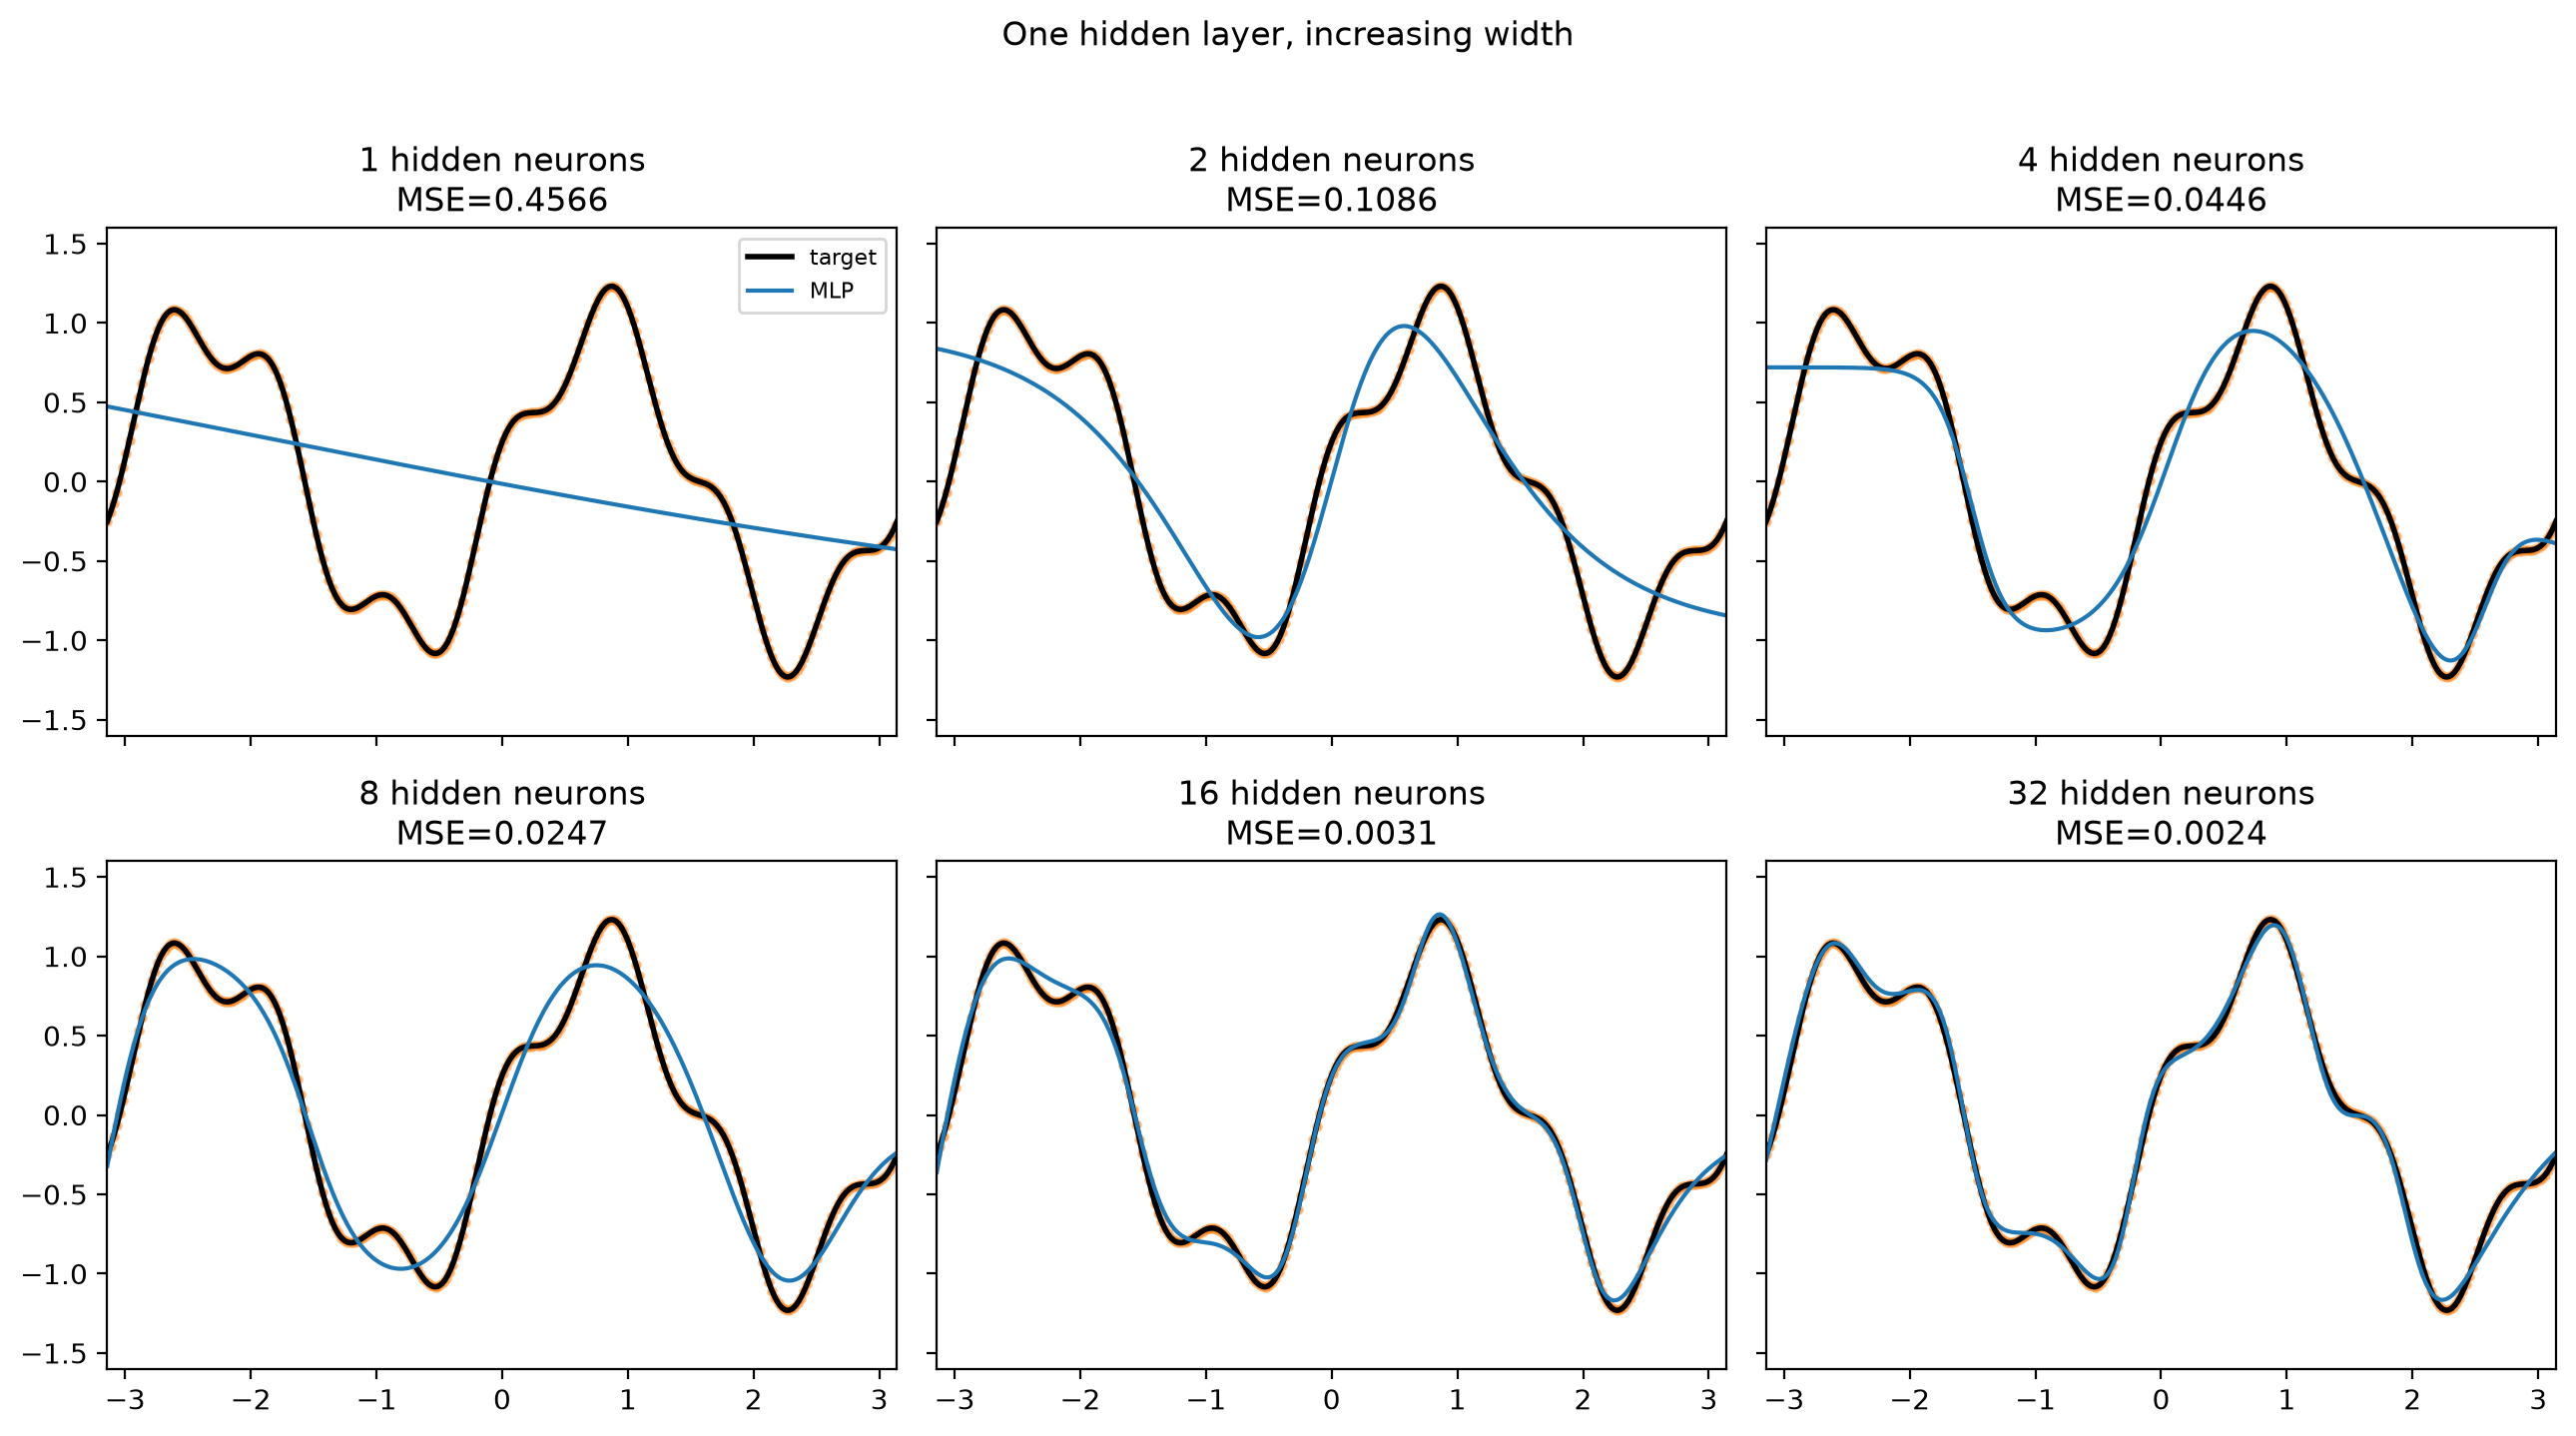

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, width in zip(axes.flat, widths):
    ax.plot(plot_x, plot_y, color='black', lw=2, label='target')
    ax.plot(plot_x, fits[width]['prediction'], color='tab:blue', label='MLP')
    ax.scatter(train_x, train_y, s=8, color='tab:orange', alpha=0.45)
    ax.set_title(f'{width} hidden neurons\nMSE={fits[width]["full_loss"]:.4f}')
    ax.set_xlim(-np.pi, np.pi)
axes[0, 0].set_ylim(-1.6, 1.6)
axes[0, 0].legend(fontsize=8)
fig.suptitle('One hidden layer, increasing width', y=1.02)
fig.tight_layout()
plt.show()

## Width and approximation error

The grid of panels shows the final fitted function for several hidden-layer widths. All widths see the same target and training points. A narrow network may miss the higher-frequency component or produce a visibly smooth approximation. Wider networks have more degrees of freedom, but width alone does not guarantee a better result if the learning rate, initialization, or number of epochs is unsuitable.

The loss is mean squared error on the sampled training points. The smooth curve drawn through a dense grid is only a visualization of the learned function; it is not an additional training signal.


## Comparing the fitted functions

The static comparison is enough for this experiment because the question is the final relationship between width and approximation error. The loss checkpoints show whether a poor final fit is caused by insufficient representation or by incomplete optimization. A wider network with a high loss throughout training has not demonstrated a capacity limit; it has not yet reached a useful parameter setting.


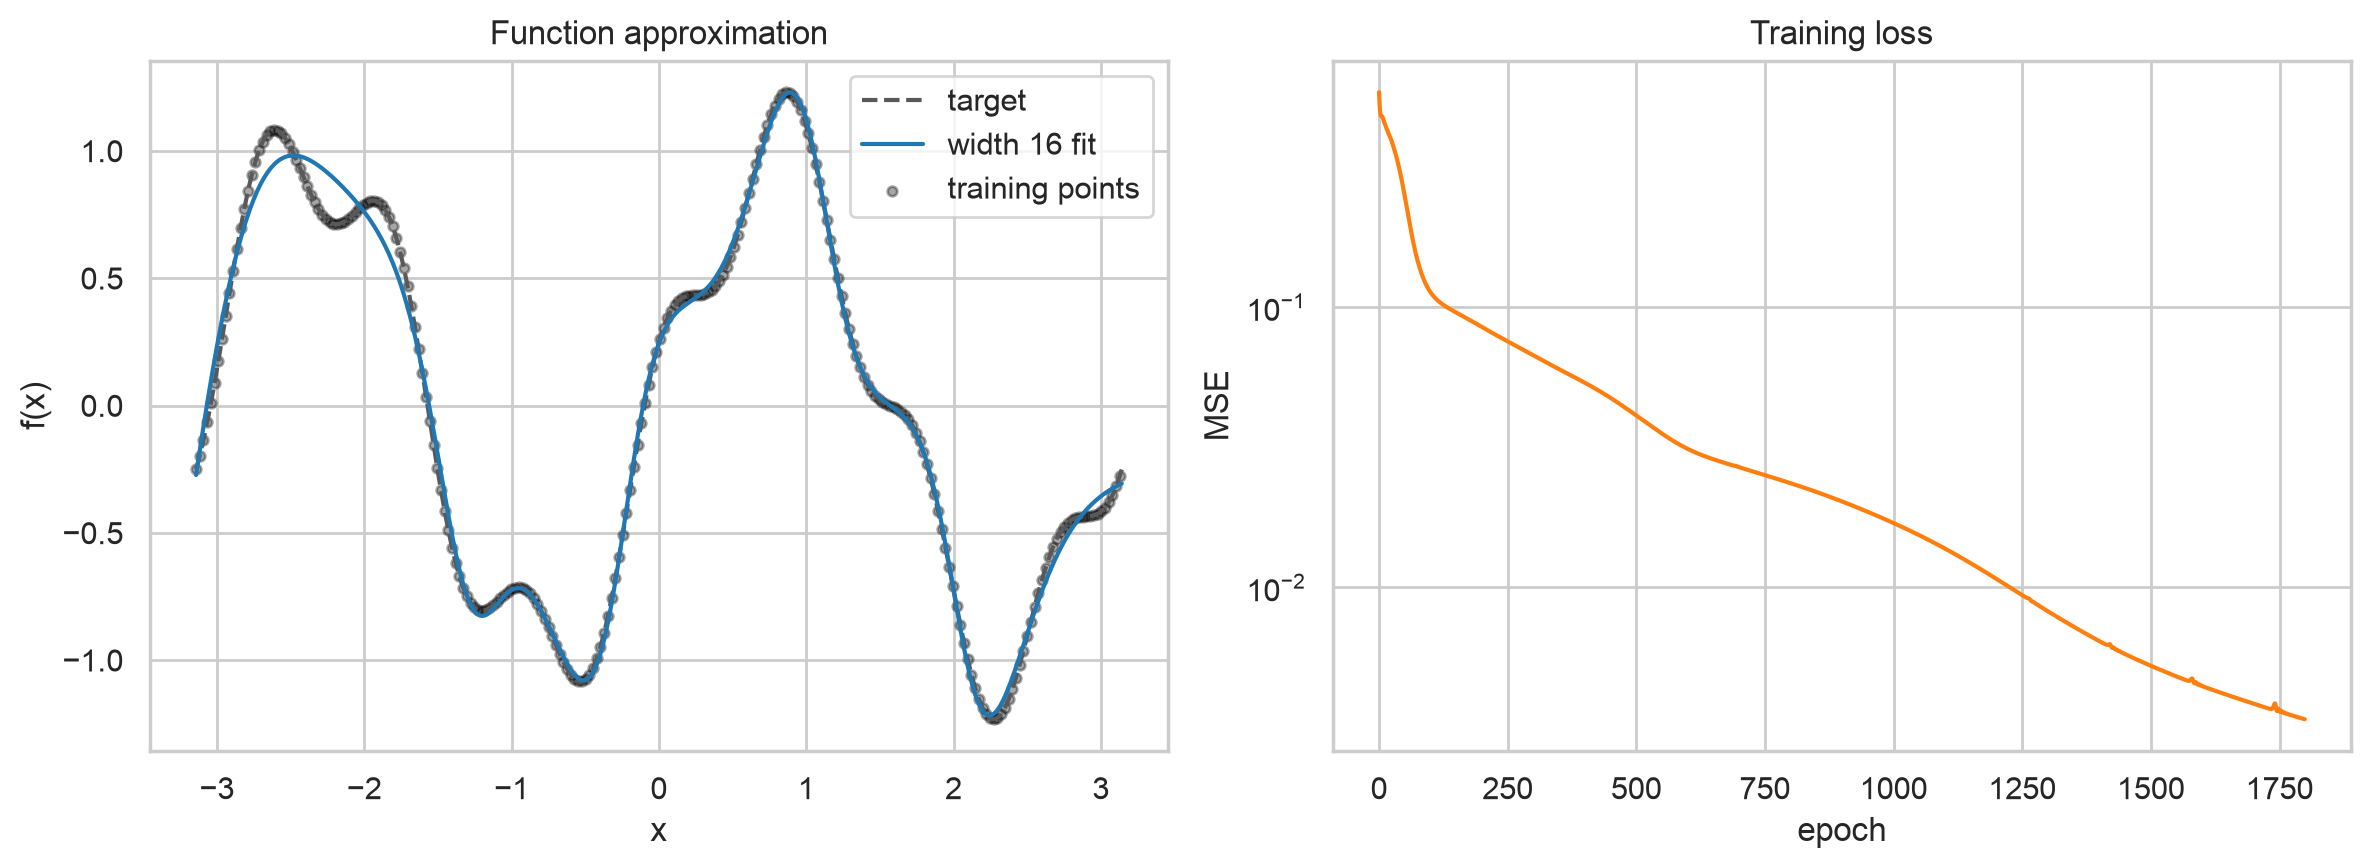

In [4]:
import pandas as pd
import seaborn as sns

width = 16
model = OneHiddenLayer(width)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
loss_history = []
for _ in range(1800):
    prediction = model(train_x)
    loss = loss_fn(prediction, train_y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

with torch.no_grad():
    fitted = model(plot_x).numpy()

curve_data = pd.DataFrame({"x": plot_x.squeeze().numpy(), "target": plot_y.squeeze().numpy(), "fitted": fitted.squeeze()})
loss_data = pd.DataFrame({"epoch": np.arange(len(loss_history)), "mse": loss_history})
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=curve_data, x="x", y="target", color="0.35", linestyle="--", ax=axes[0], label="target")
sns.lineplot(data=curve_data, x="x", y="fitted", color="tab:blue", ax=axes[0], label="width 16 fit")
axes[0].scatter(train_x.numpy(), train_y.numpy(), s=12, color="black", alpha=0.35, label="training points")
axes[0].set(title="Function approximation", xlabel="x", ylabel="f(x)")
axes[0].legend()
sns.lineplot(data=loss_data, x="epoch", y="mse", color="tab:orange", ax=axes[1])
axes[1].set(yscale="log", title="Training loss", ylabel="MSE")
fig.tight_layout()
plt.show()


## Depth and composition

A single hidden layer is sufficient in principle for continuous approximation on a compact interval, but depth changes how functions are represented. Multiple layers can compose simpler transformations and may represent some structures with fewer units than a shallow network. The theorem does not make shallow networks the preferred engineering choice; it separates representational possibility from the practical questions of optimization, parameter count, and generalization.
